In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, ttest_ind, f_oneway

plt.rcParams["figure.figsize"] = (10, 6)

In [13]:
df = pd.read_csv("../data/processed/superstore_clean.csv")
df["order_date"] = pd.to_datetime(df["order_date"])
df["ship_date"] = pd.to_datetime(df["ship_date"])
# shipping_days, order_year, order_month, profit_margin already exist from cleaning step
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,sub_category,product_name,sales,quantity,discount,profit,shipping_days,order_year,order_month,profit_margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3,2016,11,0.1600
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3,2016,11,0.3000
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4,2016,6,0.4700
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7,2015,10,-0.4000
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7,2015,10,0.1125


In [14]:
print("=" * 50)
print("DATASET INFORMATION")
print("=" * 50)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nData Types")
print(df.dtypes)

DATASET INFORMATION
Rows: 9994
Columns: 25

Data Types
row_id                    int64
order_id                    str
order_date       datetime64[us]
ship_date        datetime64[us]
ship_mode                   str
customer_id                 str
customer_name               str
segment                     str
country                     str
city                        str
state                       str
postal_code               int64
region                      str
product_id                  str
category                    str
sub_category                str
product_name                str
sales                   float64
quantity                  int64
discount                float64
profit                  float64
shipping_days             int64
order_year                int64
order_month               int64
profit_margin           float64
dtype: object


In [15]:
df[["sales", "profit", "discount", "quantity", "shipping_days"]].describe()

,sales,profit,discount,quantity,shipping_days
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,28.656896,0.156203,3.789574,3.958175
std,623.245101,234.260108,0.206452,2.225110,1.747567
min,0.444000,-6599.978000,0.000000,1.000000,0.000000
25%,17.280000,1.728750,0.000000,2.000000,3.000000
50%,54.490000,8.666500,0.200000,3.000000,4.000000
75%,209.940000,29.364000,0.200000,5.000000,5.000000
max,22638.480000,8399.976000,0.800000,14.000000,7.000000


In [16]:
corr, p_value = pearsonr(df["sales"], df["profit"])

print("=" * 50)
print("PEARSON CORRELATION TEST")
print("=" * 50)

print(f"Correlation Coefficient : {corr:.4f}")
print(f"P-value                 : {p_value:.10f}")

PEARSON CORRELATION TEST
Correlation Coefficient : 0.4791
P-value                 : 0.0000000000


# Pearson Correlation Test

This test measures the linear relationship between **Sales** and **Profit**.

### Hypotheses
- **H₀ (Null Hypothesis):** There is no significant linear relationship between Sales and Profit.
- **H₁ (Alternative Hypothesis):** There is a significant linear relationship between Sales and Profit.

If the p-value is less than **0.05**, we reject the null hypothesis.

In [17]:
tech_profit = df[df["category"] == "Technology"]["profit"]
furniture_profit = df[df["category"] == "Furniture"]["profit"]

t_stat, p_value = ttest_ind(tech_profit, furniture_profit)

print("=" * 50)
print("INDEPENDENT T-TEST")
print("=" * 50)

print(f"T Statistic : {t_stat:.4f}")
print(f"P-value     : {p_value:.10f}")

INDEPENDENT T-TEST
T Statistic : 7.1232
P-value     : 0.0000000000


# Independent T-Test

This test compares the **average profit** between the Technology and Furniture categories.

### Hypotheses
- **H₀:** The average profit of Technology and Furniture is equal.
- **H₁:** The average profit is different.

In [18]:
consumer = df[df["segment"] == "Consumer"]["sales"]
corporate = df[df["segment"] == "Corporate"]["sales"]
home_office = df[df["segment"] == "Home Office"]["sales"]

f_stat, p_value = f_oneway(consumer, corporate, home_office)

print("=" * 50)
print("ONE-WAY ANOVA")
print("=" * 50)

print(f"F Statistic : {f_stat:.4f}")
print(f"P-value     : {p_value:.10f}")

ONE-WAY ANOVA
F Statistic : 0.5952
P-value     : 0.5514734706


# One-Way ANOVA

This test determines whether **average sales differ across customer segments**.

### Hypotheses
- **H₀:** All customer segments have the same average sales.
- **H₁:** At least one customer segment has a different average sales value.

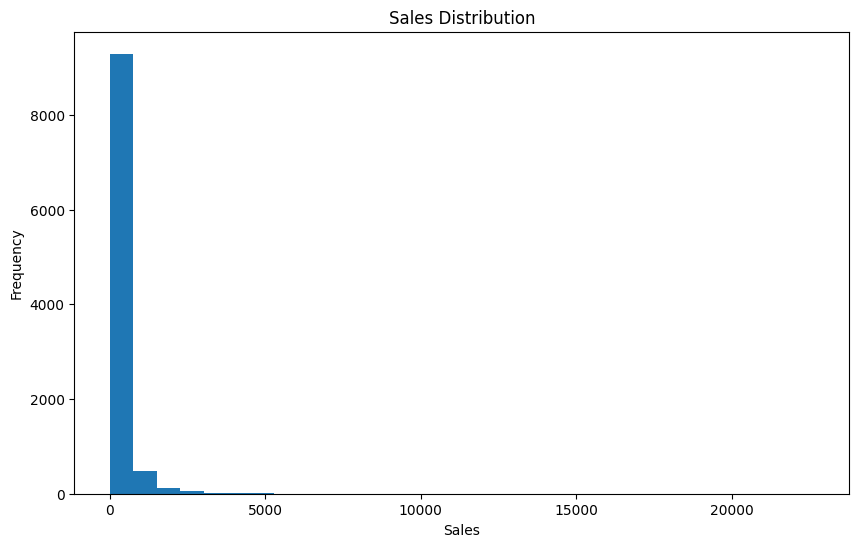

In [19]:
plt.hist(df["sales"], bins=30)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

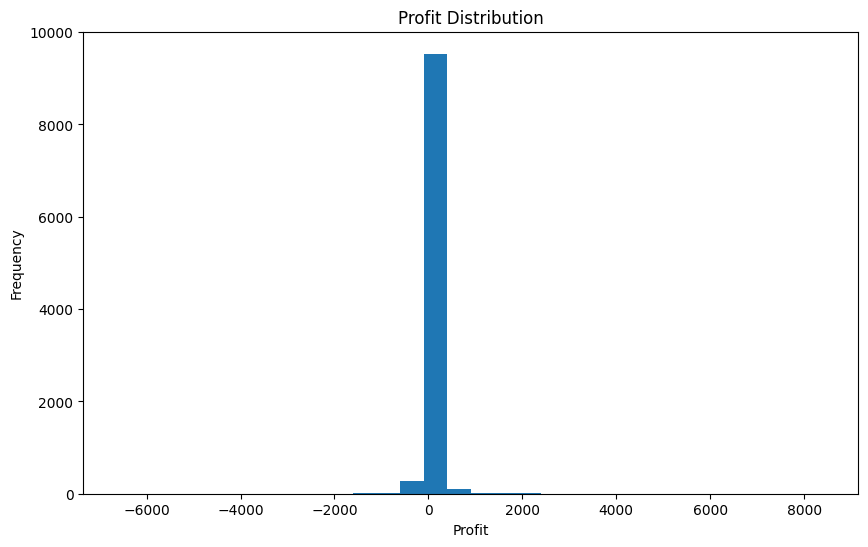

In [20]:
plt.hist(df["profit"], bins=30)
plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

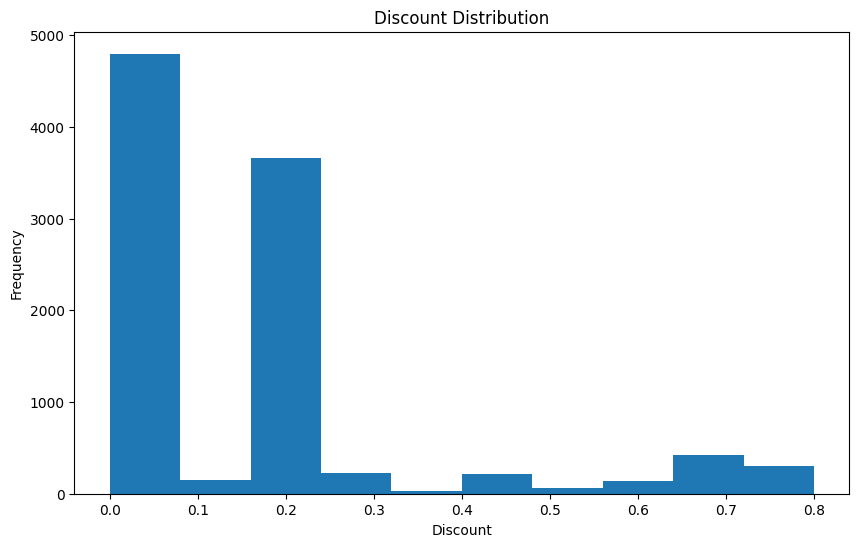

In [21]:
plt.hist(df["discount"], bins=10)
plt.title("Discount Distribution")
plt.xlabel("Discount")
plt.ylabel("Frequency")
plt.show()

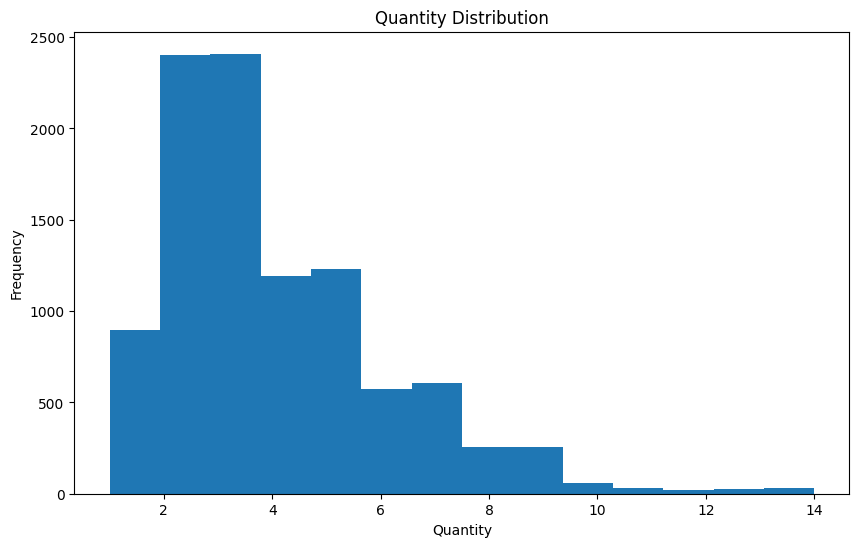

In [22]:
plt.hist(df["quantity"], bins=14)
plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

# Statistical Test Results — fill this in with your actual output numbers once cells 5, 7, 9 run